In [65]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.constants import Boltzmann

In [66]:
#Create a lattice 
#Create a vacancy
#Render the lattice
#Using random walk make the vacancy move
#Now the vacancy can move anywhere 
#Introduce Monte Carlo. 

In [67]:
class Lattice:
    def __init__(self,length=10,numVac=1,seed=42):
        
        np.random.seed(seed)

        self.length = length
        self.numVac = numVac

        #Create the lattice (grid)
        self.grid = np.ones((length,length), dtype=int)

        #Creating vacancies
        self.vacancy = []

        choices = np.random.choice(length*length,numVac,replace=False)

        for idx in choices:
            x = idx // length
            y = idx % length

            self.grid[x,y] = 0 
            self.vacancy.append([x,y])

        print("Created lattice!")
    
    def printLattice(self):
        atoms = np.argwhere(self.grid == 1)
        vacancies = np.argwhere(self.grid == 0)
        

        if len(atoms) > 0:
            plt.scatter(atoms[:,0],atoms[:,1],c="blue")
        if len(vacancies) > 0:
            plt.scatter(vacancies[:,0],vacancies[:,1],c="red")
        
        
        plt.show()
    
    def generateRandomWalk(self,iterations=5):

        length = self.length

        directions = [[1,0],[-1,0],[0,1],[0,-1]]
        
        for _ in range(iterations):
            for i , (x,y) in enumerate(self.vacancy):
                idx = np.random.choice(len(directions))

                dx,dy = directions[idx][0],directions[idx][1]

                newX = (x + dx) % length
                newY = (y+dy) % length

                self.grid[x,y] = 1
                self.grid[newX,newY] = 0

                self.vacancy[i] = [newX,newY]
            
            self.printLattice()
        
    def rejectionKMC(self, activationEnergy, Temperature=273, iterations=5):

        kB = 8.617e-5   # eV/K
        length = self.length
        directions = [[1,0],[-1,0],[0,1],[0,-1]]

        jumpProb = np.exp(-activationEnergy / (kB * Temperature))

        for _ in range(iterations):

            for i, (x, y) in enumerate(self.vacancy):

                idx = np.random.choice(len(directions))
                dx, dy = directions[idx]

                newX = (x + dx) % length
                newY = (y + dy) % length

                if np.random.rand() < jumpProb:

                    self.grid[x, y] = 1
                    self.grid[newX, newY] = 0
                    self.vacancy[i] = [newX, newY]

            self.printLattice()
    
    def rejectionFreeKMC(self, activationEnergy, Temperature=273, iterations=5):

        kB = 8.617e-5     # eV/K
        nu = 1e13         # attempt frequency (1/s)

        length = self.length
        directions = [[1,0],[-1,0],[0,1],[0,-1]]

        rate = nu * np.exp(-activationEnergy / (kB * Temperature))

        time = 0.0

        for _ in range(iterations):

            events = []

            for i, (x, y) in enumerate(self.vacancy):

                for dx, dy in directions:
                    newX = (x + dx) % length
                    newY = (y + dy) % length

                    events.append((i, x, y, newX, newY))

            totalRate = len(events) * rate

           
            chosenIndex = np.random.randint(len(events))
            i, x, y, newX, newY = events[chosenIndex]

            self.grid[x, y] = 1
            self.grid[newX, newY] = 0
            self.vacancy[i] = [newX, newY]

            dt = -np.log(np.random.rand()) / totalRate
            time += dt

            self.printLattice()

        print("Simulation time:", time)


                


In [68]:
myLattice  = Lattice(numVac=10)

Created lattice!


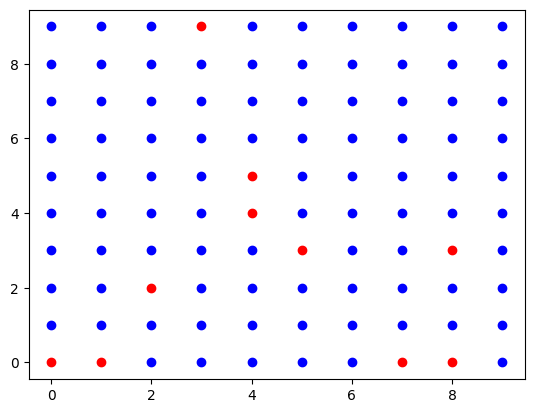

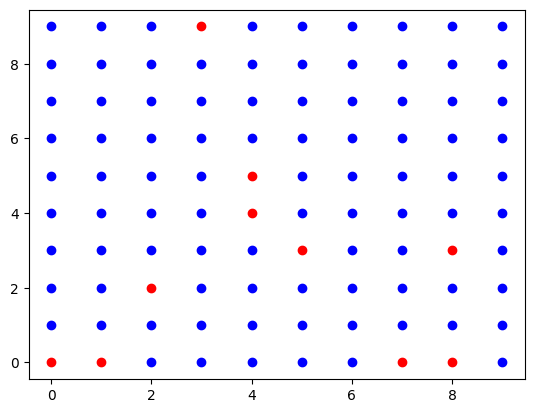

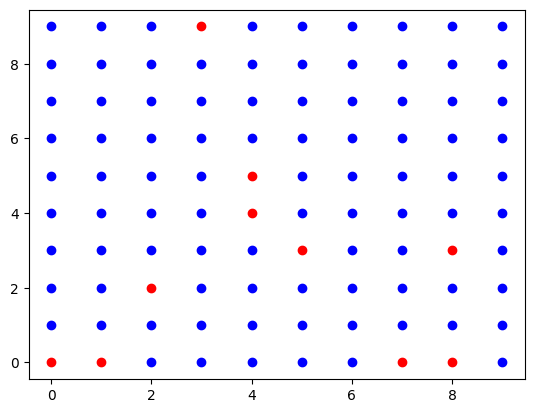

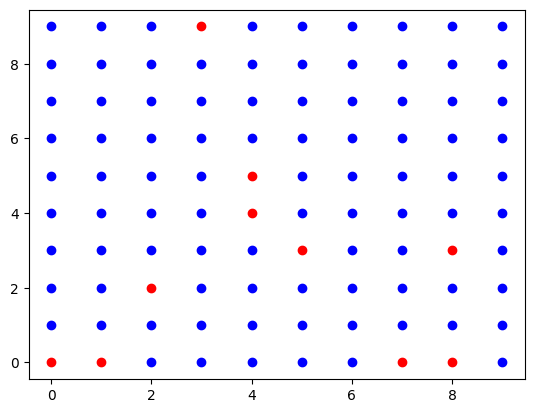

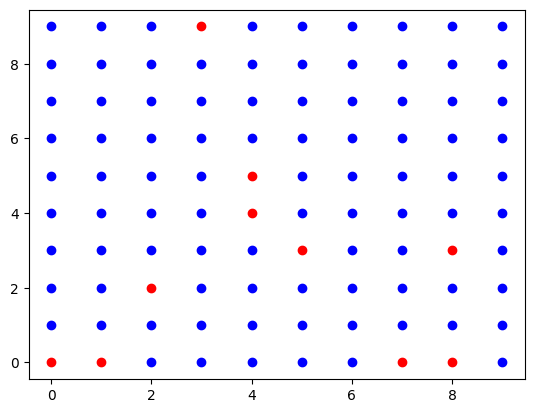

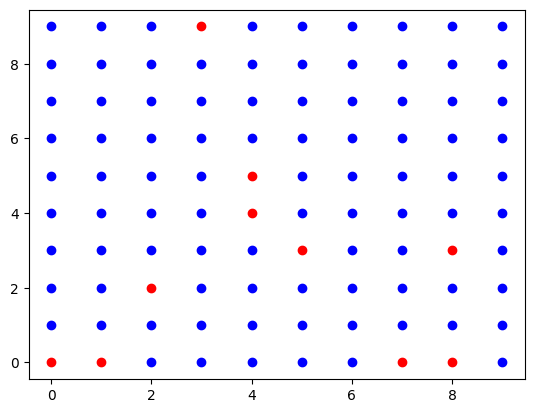

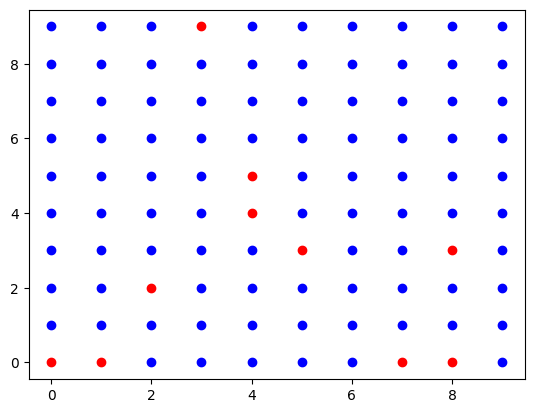

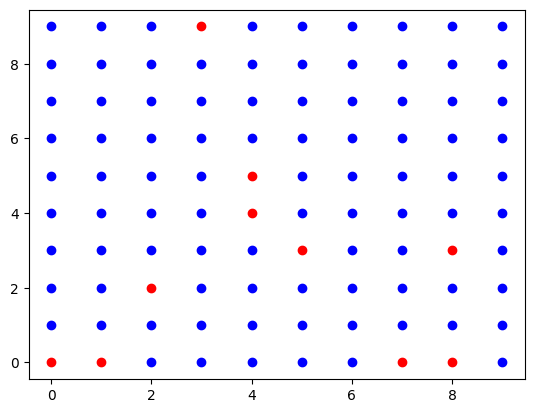

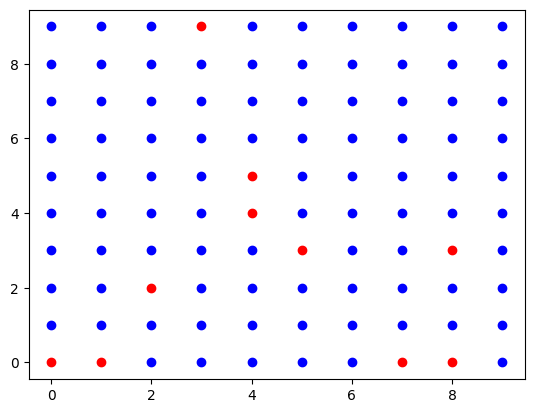

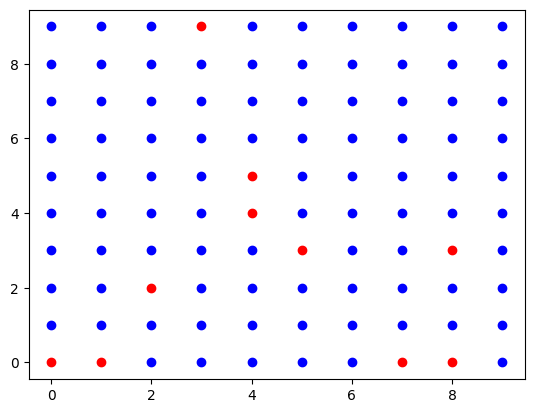

In [69]:
myLattice.rejectionKMC(50,100000,iterations=10)